<a href="https://colab.research.google.com/github/skroy57099-ux/Analyse-Financial-Market-Data-of-AI-companies-with-Python/blob/main/Analyse_Financial_Market_Data_of_AI_companies_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# import the required python libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Loading the data
data = pd.read_csv('/content/ai_financial_market_daily_realistic_synthetic.csv')
data.head()


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Index,Place
0,01-01-2015,OpenAI,5.92,0.63,-36.82,NaN,-0.36,0.0,New york
1,02-01-2015,OpenAI,5.41,1.81,80.59,NaN,0.41,1.0,New york
2,03-01-2015,OpenAI,4.50,0.61,-38.88,NaN,0.23,2.0,New york
3,04-01-2015,OpenAI,5.45,0.95,-5.34,NaN,0.93,3.0,New york
4,05-01-2015,OpenAI,3.40,1.48,48.45,NaN,-0.09,4.0,New york


In [7]:
#cleaning the data
data.duplicated().sum()
data.notnull().sum()

,0
Date,10959
Company,10959
R&D_Spending_USD_Mn,10959
AI_Revenue_USD_Mn,10959
AI_Revenue_Growth_%,10959
Event,233
Stock_Impact_%,10959
Index,1662
Place,870


In [8]:
data.drop(columns = 'Index',inplace= True)

In [9]:
data.drop(columns = 'Place',inplace= True)

In [10]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,01-01-2015,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,02-01-2015,OpenAI,5.41,1.81,80.59,NaN,0.41
2,03-01-2015,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,04-01-2015,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,05-01-2015,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [11]:
#Get some info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [12]:
data.describe()

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
count,10959.000000,10959.000000,10959.000000,10959.000000
mean,65.184504,44.126571,159.395988,0.025560
std,47.918247,41.639356,135.462185,0.749513
min,1.570000,-0.550000,-155.430000,-3.000000
25%,8.640000,3.610000,43.870000,-0.500000
50%,70.960000,35.220000,133.750000,0.000000
75%,99.600000,71.680000,258.300000,0.510000
max,163.830000,155.960000,565.500000,18.500000


In [13]:
data[data['R&D_Spending_USD_Mn'] == 163.830000] # Details company with max spending

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
7152,31-07-2024,Google,163.83,154.99,416.62,NaN,-0.68


In [14]:
data[data['AI_Revenue_USD_Mn'] == 155.960000]  # Detail of company with max Revenue

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
6952,13-01-2024,Google,158.72,155.96,419.88,NaN,0.56
7244,31-10-2024,Google,161.26,155.96,419.85,NaN,0.27


In [15]:
data[data['AI_Revenue_Growth_%'] == 565.500000]  # Detail of company with max Revenue Growth

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3423,16-05-2024,OpenAI,8.47,6.65,565.5,NaN,0.51


In [16]:
data[data['R&D_Spending_USD_Mn'] == 1.570000]   # Detail of company with min R&D spending

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
1054,20-11-2017,OpenAI,1.57,1.78,77.62,NaN,0.7


In [17]:
data[data['Stock_Impact_%']== 18.500000]   #Detail of company with max stock impact

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3408,01-05-2024,OpenAI,10.91,5.34,434.27,GPT-5 release (predicted),18.5


In [18]:
data[data['Stock_Impact_%']==-3.000000]     #Detail of company with min stock impact

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
3350,04-03-2024,OpenAI,10.82,4.77,376.53,AI Ads Optimization upgrade,-3.0


In [19]:
#Q.1) How much amount the companies spent on R & D ?
data['R&D_Spending_USD_Mn'].sum()

np.float64(714356.98)

In [20]:
data.groupby('Company')['R&D_Spending_USD_Mn'].sum()

,R&D_Spending_USD_Mn
Company,
Google,423341.14
Meta,264533.07
OpenAI,26482.77


Text(0, 0.5, 'R&D_Spending_USD_Mn')

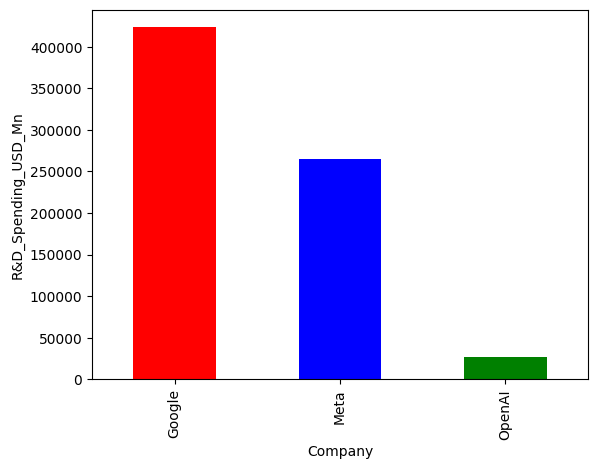

In [21]:
data.groupby('Company')['R&D_Spending_USD_Mn'].sum().plot(kind='bar', color=['red', 'blue', 'green'])
plt.ylabel('R&D_Spending_USD_Mn')

In [22]:
#Q.2) Revenue Earned by the companies
data['AI_Revenue_USD_Mn'].sum()

np.float64(483583.09)

In [23]:
data.groupby('Company')['AI_Revenue_USD_Mn'].sum()

,AI_Revenue_USD_Mn
Company,
Google,284498.38
Meta,189621.82
OpenAI,9462.89


Text(0, 0.5, 'AI_Revenue_USD_Mn')

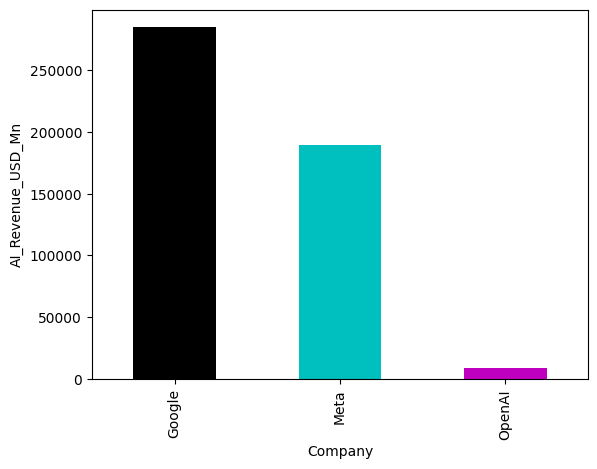

In [24]:
data.groupby('Company')['AI_Revenue_USD_Mn'].sum().plot(kind='bar', color=['k', 'c', 'm'])
plt.ylabel('AI_Revenue_USD_Mn')

In [25]:
#Q.3) Date-wise Impact on the Stock
data.groupby('Date')['Stock_Impact_%'].sum()


,Stock_Impact_%
Date,
01-01-2015,-0.80
01-01-2016,1.80
01-01-2017,0.47
01-01-2018,1.21
01-01-2019,1.03
...,...
31-12-2020,-1.11
31-12-2021,-1.30
31-12-2022,0.68


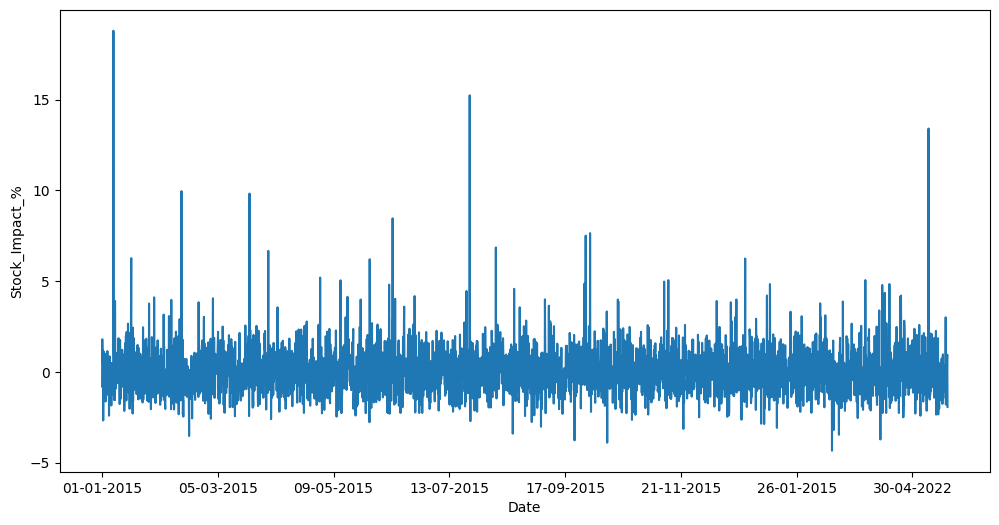

In [26]:
data.groupby('Date')['Stock_Impact_%'].sum().plot(kind='line',figsize=(12,6))
plt.ylabel('Stock_Impact_%')
plt.style.use('dark_background')


In [27]:
#Q.4) Events when Maximum Stock Impact was observed
data.groupby('Event')['Stock_Impact_%'].max()

,Stock_Impact_%
Event,
AI Ads Optimization upgrade,4.63
AI Video Recommendation upgrade,4.80
AI ethics policy update,4.88
AI partnership deal,4.96
AI speech recognition release,4.82
AI-powered search update,4.79
AlphaGo beats Lee Sedol,6.20
BERT for Search launch,3.20
Bard chatbot launch,5.00


Text(0, 0.5, 'Event')

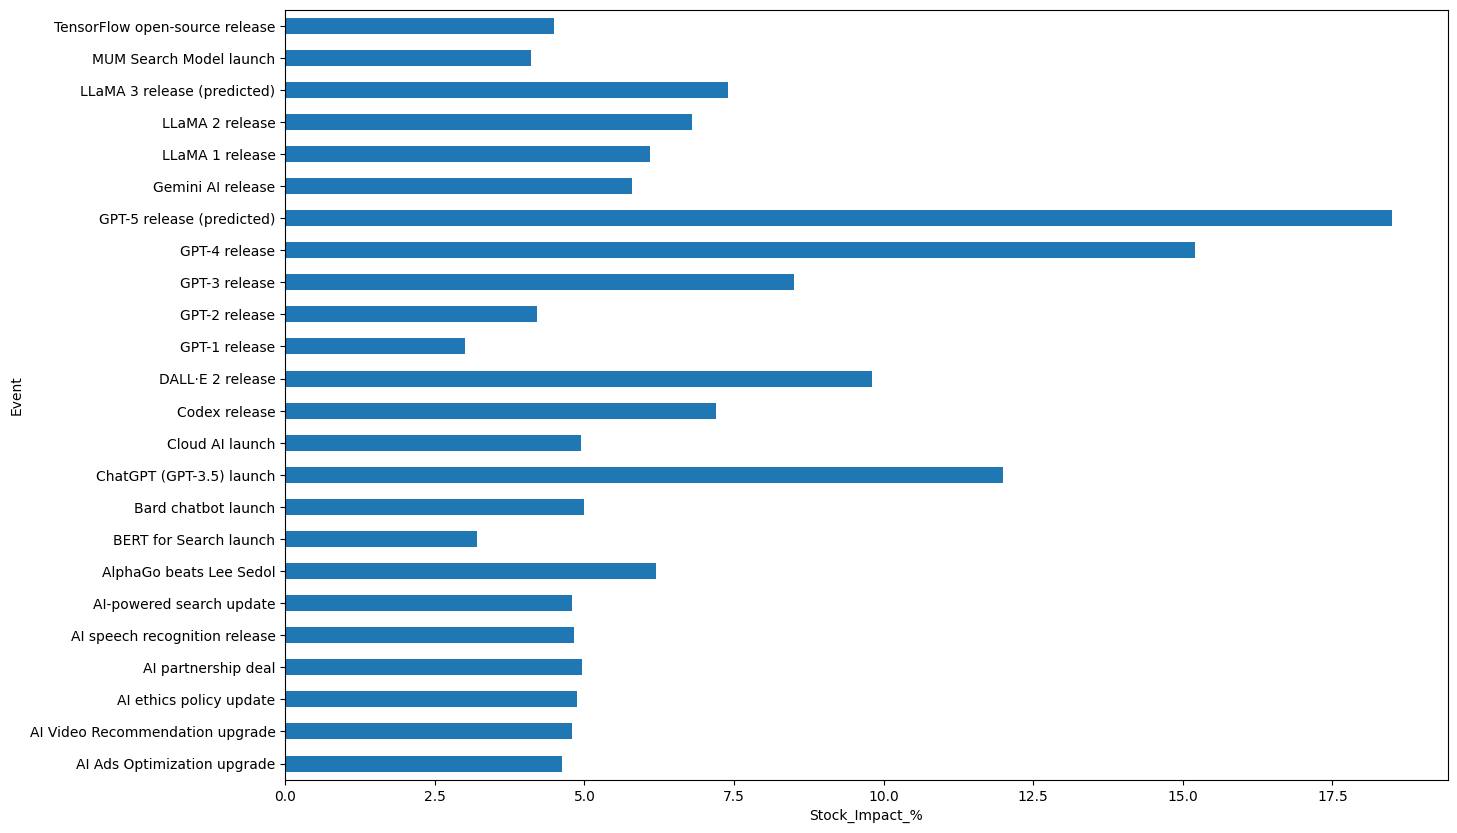

In [28]:
plt.style.use('default')
data.groupby('Event')['Stock_Impact_%'].max().plot(kind='barh', figsize=(15,10))
plt.xlabel('Stock_Impact_%')
plt.ylabel('Event')

In [29]:
#Q.5) AI Revenue Growth of the companies
data.groupby('Company')['AI_Revenue_Growth_%'].sum()

,AI_Revenue_Growth_%
Company,
Google,583027.25
Meta,582807.74
OpenAI,580985.64


Text(0.5, 1.0, 'AI Revenue Growth of the companies')

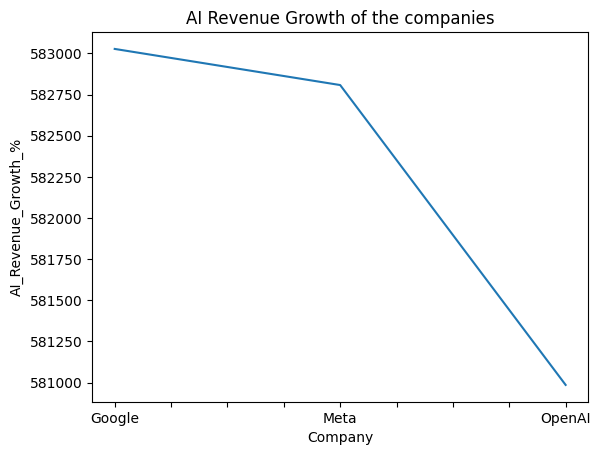

In [30]:
data.groupby('Company')['AI_Revenue_Growth_%'].sum().plot(kind='line')
plt.ylabel('AI_Revenue_Growth_%')
plt.title('AI Revenue Growth of the companies')

In [31]:
#Q.6) Correlation between the columns
data.corr(numeric_only=True)

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000


In [32]:
data.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
R&D_Spending_USD_Mn,1.000000,0.935030,0.291245,-0.004628
AI_Revenue_USD_Mn,0.935030,1.000000,0.530128,-0.000017
AI_Revenue_Growth_%,0.291245,0.530128,1.000000,0.020937
Stock_Impact_%,-0.004628,-0.000017,0.020937,1.000000


Text(0.5, 1.0, 'Correlation between the columns')

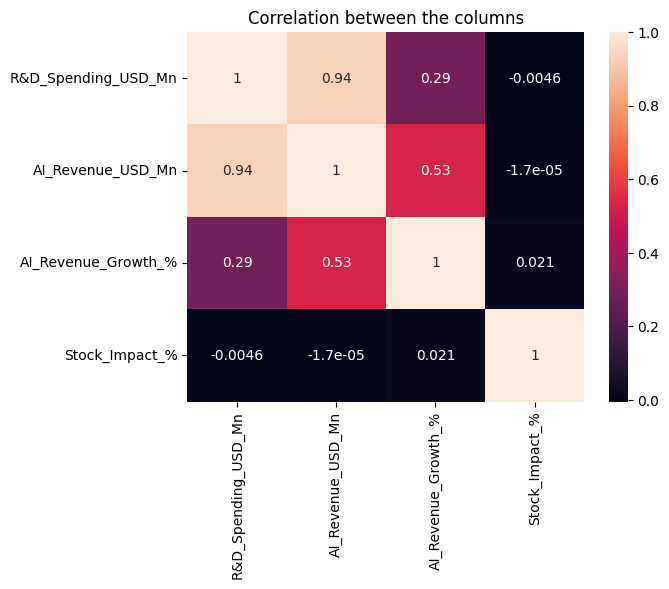

In [33]:
data.corr(numeric_only=True)
sns.heatmap(data.corr(numeric_only= True), annot=True)
plt.title('Correlation between the columns')

In [41]:
#Q.7) Expenditure vs Revenue year-by-year
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
data['Year'] = data['Date'].dt.year
data.groupby('Year')[['AI_Revenue_USD_Mn','R&D_Spending_USD_Mn']].sum()

,AI_Revenue_USD_Mn,R&D_Spending_USD_Mn
Year,,
2015,18623.21,49304.23
2016,22361.20,53349.94
2017,26776.80,57475.12
2018,32164.44,62002.16
2019,38580.32,67071.51
2020,46456.19,72602.53
2021,55591.14,78207.32
2022,66674.24,84390.17
2023,80041.64,91193.92


Text(0.5, 1.0, 'Expenditure vs Revenue year-by-year')

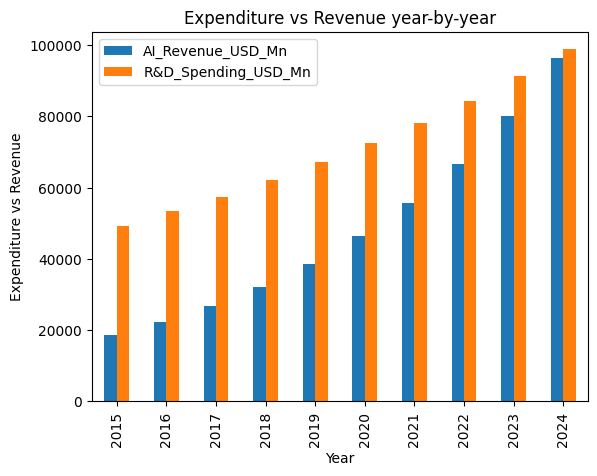

In [42]:
data.groupby('Year')[['AI_Revenue_USD_Mn','R&D_Spending_USD_Mn']].sum().plot(kind='bar')
plt.ylabel('Expenditure vs Revenue')
plt.title('Expenditure vs Revenue year-by-year')

(Text(0.5, 0, 'Change in the index'),
 Text(0, 0.5, 'Year & Company'),
 Text(0.5, 1.0, 'Change in the stock wrt Year & Company'))

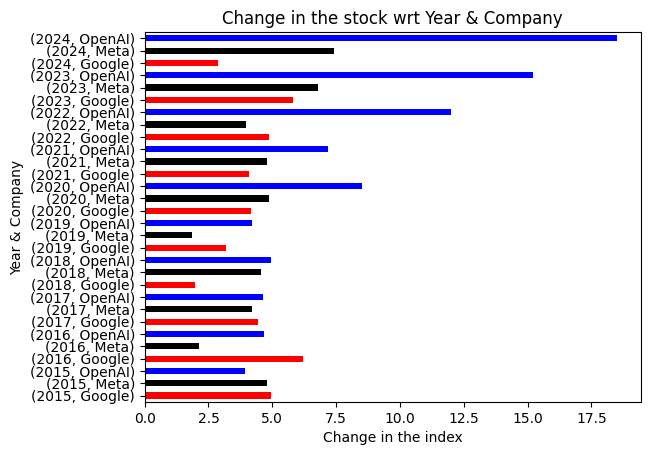

In [43]:
#Q.8) Change in the stock wrt Year & Company
data.groupby(['Year','Company'])['Stock_Impact_%'].max().plot(kind='barh',color = ['red','black','blue'])
plt.xlabel('Change in the index'), plt.ylabel('Year & Company'), plt.title('Change in the stock wrt Year & Company')

Text(0.5, 0, 'Event Impact Analysis')

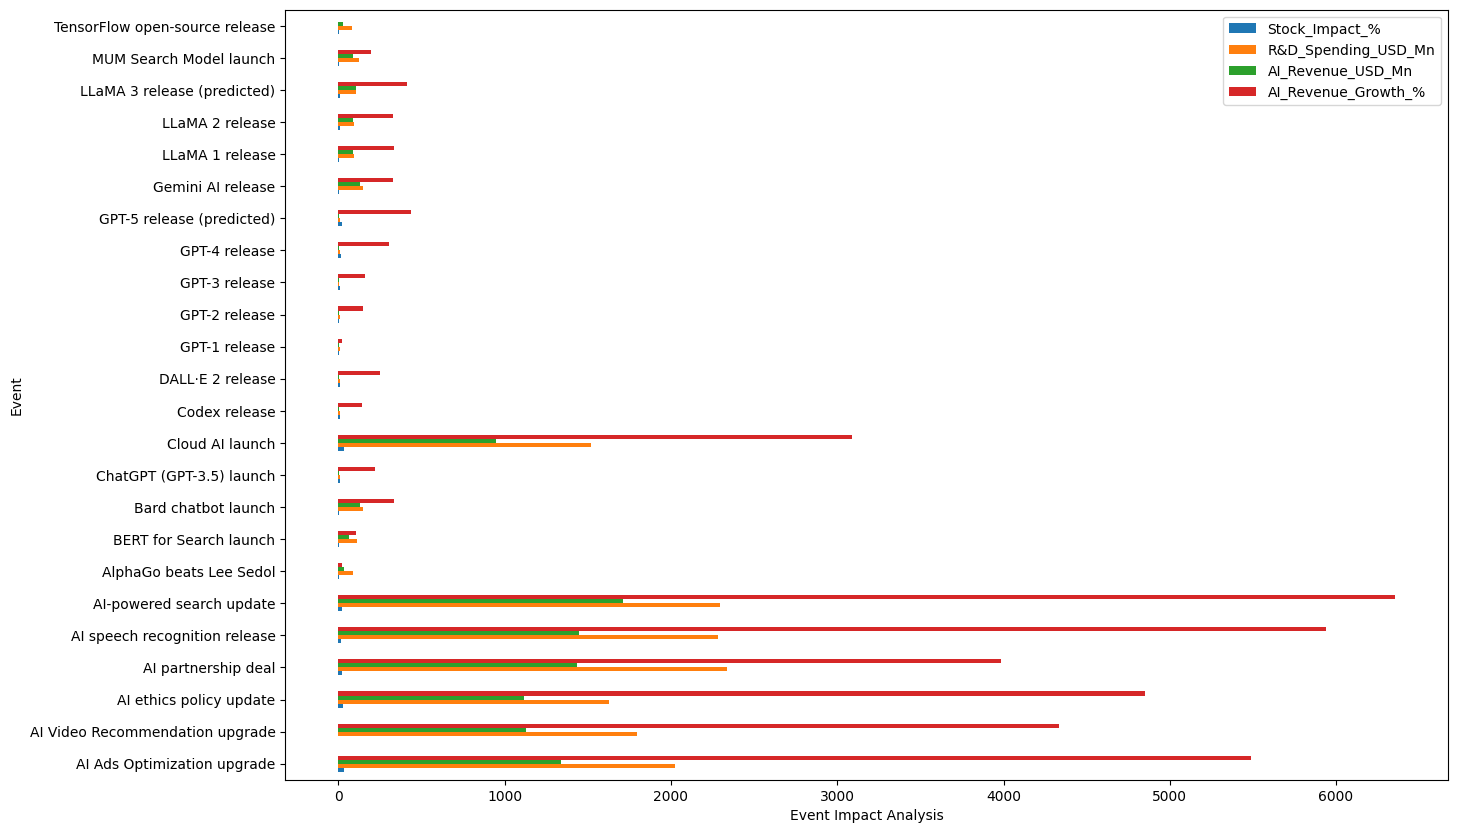

In [39]:
#Q.9) Event Impact Analysis
data.groupby('Event')[['Stock_Impact_%','R&D_Spending_USD_Mn','AI_Revenue_USD_Mn','AI_Revenue_Growth_%']].sum().plot(kind='barh',figsize=(15,10))
plt.xlabel('Event Impact Analysis')

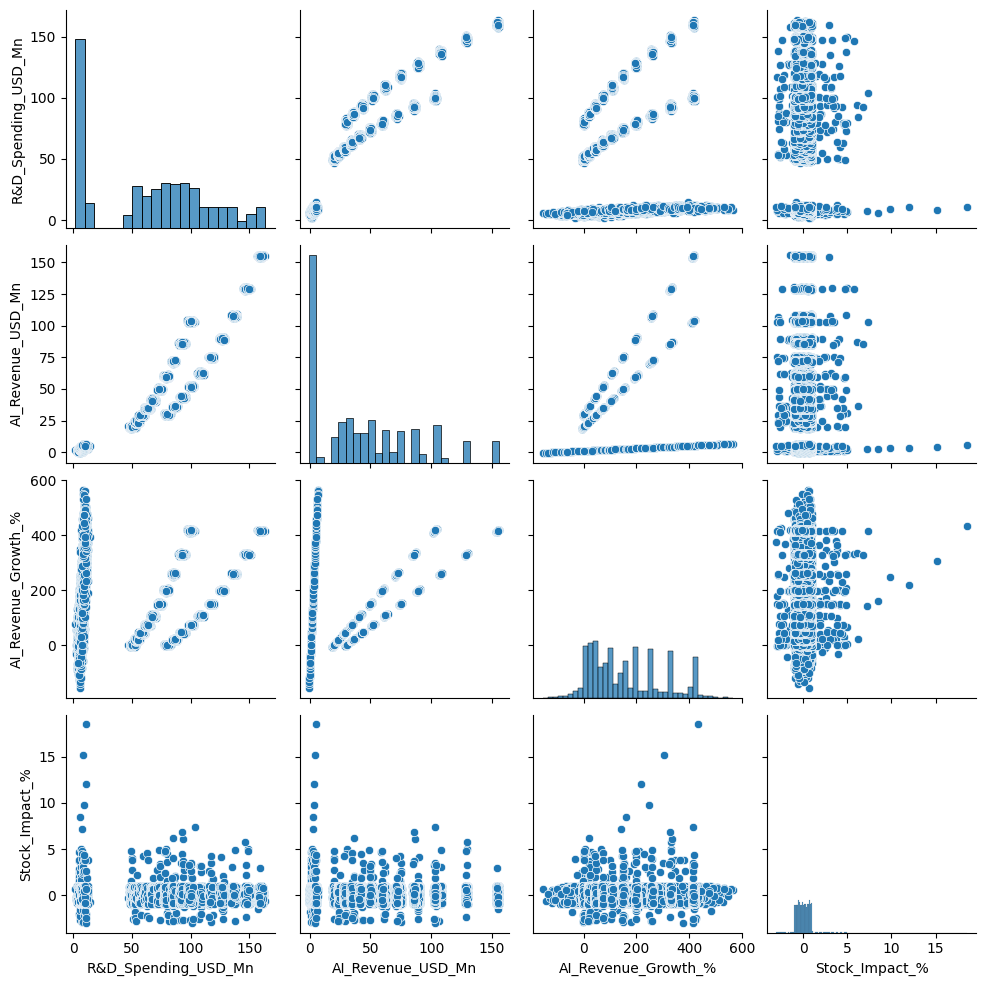

In [40]:
sns.pairplot(data)